# CFP soft-threshold scoring on the screws dataset

Este notebook complementa `docs/cfp-scoring-design.md` com um experimento pequeno no dataset `screws_segmentation`. O foco agora e mostrar o scorer de threshold suave `SingleAttributeSoftThresholdScorer`, registrado como `single_attribute_soft_threshold`, aplicado a um unico atributo morfologico.

O experimento nao treina uma rede de segmentacao completa. Ele usa a camada CFP como filtro morfologico parametrizado, normaliza a resposta filtrada e mede F1/IoU contra as mascaras de parafusos.

In [1]:
from pathlib import Path
import sys
import time

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
repo_root = next(
    (
        p
        for p in (cwd, *cwd.parents)
        if (p / "pyproject.toml").exists()
        and (p / "mtlearn" / "python" / "mtlearn").exists()
    ),
    cwd,
)
for candidate in [
    repo_root / "build" / "mtlearn" / "bindings",
    repo_root / "mtlearn" / "python",
]:
    if candidate.exists() and str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

torch.manual_seed(42)
np.random.seed(42)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("repo_root:", repo_root)
print("device:", DEVICE)

repo_root: /Volumes/SSD/GitHub/mtlearn
device: mps


In [2]:
import mtlearn
from mtlearn import morphology
from mtlearn.layers import ConnectedFilterPreprocessingLayer
from mtlearn.layers import cfp
from mtlearn.layers.cfp.scoring import ScoringModel

## Soft-threshold scorer

Esta celula segue o design do guia: `SingleAttributeSoftThresholdScorer` aprende explicitamente o limiar `lambda` de um unico atributo. A suavidade da transicao fica no hiperparametro da camada `beta_f`, o mesmo usado pelos scorers CFP existentes.

In [3]:
class SingleAttributeSoftThresholdScorer(ScoringModel):
    kind = "single_attribute_soft_threshold"

    def __init__(self, num_features: int, *, initial_lambda: float = 0.5):
        super().__init__()
        if int(num_features) != 1:
            raise ValueError("single_attribute_soft_threshold requires exactly one feature.")
        self.num_features = int(num_features)
        self.initial_lambda = float(initial_lambda)
        self.lambda_ = torch.nn.Parameter(torch.tensor(self.initial_lambda, dtype=torch.float32))

    def forward(self, features, tree_info=None, context=None, *, beta_f=None, clamp=None):
        if features.dim() != 2:
            raise ValueError(f"expected features with shape (num_nodes, K), got {tuple(features.shape)}")
        if features.size(1) != self.num_features:
            raise ValueError(f"expected {self.num_features} features, got {features.size(1)}")

        attribute = features[:, 0]
        lambda_value = self.lambda_.to(dtype=features.dtype, device=features.device)
        logits = attribute - lambda_value
        beta = 1.0 if beta_f is None else float(beta_f)
        scaled = beta * logits
        if clamp is not None:
            scaled = torch.clamp(scaled, clamp[0], clamp[1])
        return torch.sigmoid(scaled)

    def to_config(self):
        return {
            "kind": self.kind,
            "initial_lambda": self.initial_lambda,
        }


def _create_single_attribute_soft_threshold_scorer(
    *,
    num_features: int,
    initial_lambda: float = 0.5,
    **options,
):
    if options:
        names = ", ".join(sorted(options))
        raise ValueError(f"unsupported single_attribute_soft_threshold scoring options: {names}")
    return SingleAttributeSoftThresholdScorer(
        num_features,
        initial_lambda=initial_lambda,
    )


if "single_attribute_soft_threshold" not in cfp.SCORING_MODEL_REGISTRY.registered_kinds():
    cfp.SCORING_MODEL_REGISTRY.register(
        "single_attribute_soft_threshold",
        _create_single_attribute_soft_threshold_scorer,
    )

features = torch.linspace(0.0, 1.0, steps=6).view(-1, 1)
demo_rows = []
for lambda_value in [0.25, 0.5, 0.75]:
    scorer = SingleAttributeSoftThresholdScorer(
        num_features=1,
        initial_lambda=lambda_value,
    )
    scores = scorer(features, beta_f=4.0, clamp=(-8.0, 8.0))
    for attr_value, score in zip(features[:, 0], scores):
        demo_rows.append(
            {
                "normalized_LENGTH_MAJOR_AXIS": float(attr_value),
                "lambda": lambda_value,
                "score": float(score.detach()),
            }
        )

pd.DataFrame(demo_rows).pivot(
    index="normalized_LENGTH_MAJOR_AXIS",
    columns="lambda",
    values="score",
)

lambda,0.25,0.50,0.75
normalized_LENGTH_MAJOR_AXIS,,,
0.0,0.268941,0.119203,0.047426
0.2,0.450166,0.231475,0.099750
0.4,0.645656,0.401312,0.197816
0.6,0.802184,0.598688,0.354344
0.8,0.900250,0.768525,0.549834
1.0,0.952574,0.880797,0.731059


## Dataset

Usamos o mesmo helper publico dos notebooks ICPR. A entrada e invertida para deixar o parafuso mais brilhante antes da max-tree, e o alvo tambem e invertido para que o foreground fique em `1`.

In [4]:
DATASET_KEY = "screws_segmentation"
SEED = 42

# Use original image size: leave numRows/numCols unset.
dataset_dir = mtlearn.data.ensure_dataset(DATASET_KEY)
dataset = mtlearn.datasets.PairedImageDataset(
    root_dir=str(dataset_dir),
    grayscale_in=True,
    invert_in=True,
    invert_target=True,
    numRows=None,
    numCols=None,
    scale_in=True,
    scale_out=True,
    suffix_in="_in",
    suffix_target="_target",
)
trainset, testset = dataset.train_test_split(test_size=0.3, random_state=SEED)
x0, y0, name0 = dataset[0]

print("dataset_dir:", dataset_dir)
print("pairs:", len(dataset), "train:", len(trainset), "test:", len(testset))
print("sample:", name0, "x:", tuple(x0.shape), "y:", tuple(y0.shape))
print("original image size (H, W):", tuple(x0.shape[-2:]))
print("x range:", float(x0.min()), float(x0.max()))
print("target foreground ratio:", float((y0 > 0.5).float().mean()))

screws_segmentation: already available at /Volumes/SSD/GitHub/mtlearn/dat/screws_segmentation
dataset_dir: /Volumes/SSD/GitHub/mtlearn/dat/screws_segmentation
pairs: 49 train: 34 test: 15
sample: 01_in.jpg x: (1, 1351, 1179) y: (1, 1351, 1179)
original image size (H, W): (1351, 1179)
x range: 0.1411764770746231 1.0
target foreground ratio: 0.019896047189831734


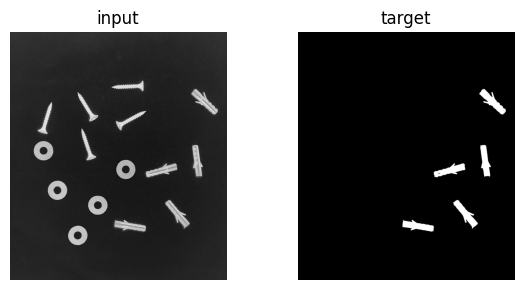

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(x0[0], cmap="gray")
axes[0].set_title("input")
axes[1].imshow(y0[0], cmap="gray", vmin=0, vmax=1)
axes[1].set_title("target")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## CFP layer with `single_attribute_soft_threshold`

A spec usa apenas `LENGTH_MAJOR_AXIS`. Como este scorer possui o parametro proprio `lambda_`, a camada nao cria os tensores legados `_weights` e `_biases`; o parametro aparece dentro do scoring model.

In [6]:
FILTER_KEY = "max_length_major_axis_soft_threshold"
ATTRIBUTE = morphology.AttributeType.LENGTH_MAJOR_AXIS
ATTRIBUTES = [ATTRIBUTE]
SCORING_CONFIG = {
    "kind": "single_attribute_soft_threshold",
    "initial_lambda": 0.95,
}

registered = cfp.SCORING_MODEL_REGISTRY.create(SCORING_CONFIG, num_features=len(ATTRIBUTES))
print("API attribute:", ATTRIBUTE.name)
print("registered scorer:", type(registered).__name__)
print("registered config:", registered.to_config())

layer = ConnectedFilterPreprocessingLayer(
    in_channels=1,
    filter_specs=[
        {
            "name": FILTER_KEY,
            "tree_type": morphology.TreeType.MAX_TREE,
            "attributes": ATTRIBUTES,
            "scoring": SCORING_CONFIG,
        }
    ],
    scale_mode="minmax01",
    device=DEVICE,
    beta_f=4.0,
    clamp=8.0,
)

print("layer scoring config:", layer.get_config()["filter_specs"][0]["scoring"])
print("layer beta_f:", layer.beta_f)
print("parameter contract:", layer.get_parameter_contract())
print("layer device:", layer.device)
print("scoring parameters:", [name for name, _ in layer._scoring_models[FILTER_KEY].named_parameters()])

API attribute: LENGTH_MAJOR_AXIS
registered scorer: SingleAttributeSoftThresholdScorer
registered config: {'kind': 'single_attribute_soft_threshold', 'initial_lambda': 0.95}
layer scoring config: {'kind': 'single_attribute_soft_threshold', 'initial_lambda': 0.95}
layer beta_f: 4.0
parameter contract: {'weights': {}, 'biases': {}, 'scoring_models': {'max_length_major_axis_soft_threshold': {'lambda_': []}}}
layer device: mps
scoring parameters: ['lambda_']


## Metric helpers

A CFP retorna uma imagem filtrada. Para comparar com a mascara binaria, normalizamos cada resposta filtrada para `[0,1]` e aplicamos um threshold. Isso mede a utilidade da resposta morfologica como sinal de segmentacao, nao o desempenho final de um modelo supervisionado completo.

In [7]:
def image_minmax01(image: torch.Tensor) -> torch.Tensor:
    image = image.float()
    return (image - image.min()) / (image.max() - image.min() + 1e-6)


def set_soft_threshold_gate(layer, lambda_value, *, key=FILTER_KEY):
    scorer = layer._scoring_models[key]
    with torch.no_grad():
        scorer.lambda_.fill_(float(lambda_value))


def binary_counts(pred: torch.Tensor, target: torch.Tensor) -> dict[str, int]:
    pred = pred.bool().reshape(-1)
    target = (target > 0.5).bool().reshape(-1)
    tp = int((pred & target).sum())
    fp = int((pred & ~target).sum())
    fn = int((~pred & target).sum())
    tn = int((~pred & ~target).sum())
    return {"tp": tp, "fp": fp, "fn": fn, "tn": tn}


def counts_to_metrics(counts: dict[str, int]) -> dict[str, float]:
    tp = counts["tp"]
    fp = counts["fp"]
    fn = counts["fn"]
    tn = counts["tn"]
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2.0 * precision * recall / (precision + recall) if precision + recall else 0.0
    iou = tp / (tp + fp + fn) if tp + fp + fn else 0.0
    accuracy = (tp + tn) / (tp + tn + fp + fn) if tp + tn + fp + fn else 0.0
    return {
        "F1": f1,
        "IoU": iou,
        "Precision": precision,
        "Recall": recall,
        "Accuracy": accuracy,
    }


def iter_limited(split, max_samples=None):
    limit = len(split) if max_samples is None else min(int(max_samples), len(split))
    for index in range(limit):
        yield split[index]


def prepare_cached_split(layer, split, *, max_samples=None, index_offset=0):
    cached = []
    for local_index, (x, y, name) in enumerate(iter_limited(split, max_samples=max_samples)):
        cache_index = int(index_offset) + local_index
        base_key = f"{cache_index}_0"
        for spec in layer.filter_specs:
            layer._ensure_tree_payload_cached(
                base_key,
                x[0],
                spec.tree_key,
                update_stats=False,
            )
        cached.append((x, y, name, cache_index))
    return cached


def layer_response(layer, sample):
    if len(sample) == 4:
        x, _, _, cache_index = sample
        idx = torch.tensor([int(cache_index)], device=layer.device)
        model_input = (x.unsqueeze(0).to(layer.device), idx)
    else:
        x = sample[0]
        model_input = x.unsqueeze(0).to(layer.device)
    return layer(model_input)[0, 0].detach().cpu()


def layer_response_train(layer, sample):
    x, _, _, cache_index = sample
    idx = torch.tensor([int(cache_index)], device=layer.device)
    return layer((x.unsqueeze(0).to(layer.device), idx))[0, 0]


def soft_dice_loss(pred: torch.Tensor, target: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    pred = pred.reshape(-1)
    target = target.reshape(-1)
    numerator = 2.0 * (pred * target).sum() + eps
    denominator = pred.sum() + target.sum() + eps
    return 1.0 - numerator / denominator


def evaluate_configuration(layer, split, lambda_value, response_threshold, *, max_samples=None):
    set_soft_threshold_gate(layer, lambda_value)
    totals = {"tp": 0, "fp": 0, "fn": 0, "tn": 0}
    with torch.no_grad():
        for sample in iter_limited(split, max_samples=max_samples):
            x, y = sample[0], sample[1]
            response = layer_response(layer, sample)
            response01 = image_minmax01(response)
            pred = response01 >= float(response_threshold)
            counts = binary_counts(pred, y[0])
            for key, value in counts.items():
                totals[key] += value
    metrics = counts_to_metrics(totals)
    metrics.update(totals)
    return metrics

## Train for 100 epochs and evaluate

O treino otimiza apenas o parametro `lambda_` do `SingleAttributeSoftThresholdScorer`. A perda principal e soft-Dice sobre a resposta CFP normalizada por imagem. Uma regularizacao leve ancora `lambda_` perto do valor inicial para preservar a leitura de limiar no espaco normalizado do atributo. A suavidade do score vem de `layer.beta_f`.

In [8]:
TRAIN_CONFIG = {
    "epochs": 100,
    "learning_rate": 0.02,
    "lambda_regularization": 0.1,
    "initial_lambda": 0.95,
    "beta_f": 4.0,
    "response_threshold": 0.85,
}

start = time.time()
train_cached = prepare_cached_split(layer, trainset, index_offset=1000)
test_cached = prepare_cached_split(layer, testset, index_offset=2000)

layer.beta_f = float(TRAIN_CONFIG["beta_f"])
set_soft_threshold_gate(
    layer,
    TRAIN_CONFIG["initial_lambda"],
)
scorer = layer._scoring_models[FILTER_KEY]
optimizer = torch.optim.Adam([scorer.lambda_], lr=TRAIN_CONFIG["learning_rate"])

history = []
for epoch in range(1, TRAIN_CONFIG["epochs"] + 1):
    optimizer.zero_grad()
    data_loss_value = 0.0

    for sample in train_cached:
        _, y, _, _ = sample
        response = layer_response_train(layer, sample)
        response01 = image_minmax01(response)
        target = y[0].to(layer.device)
        sample_loss = soft_dice_loss(response01, target) / float(len(train_cached))
        sample_loss.backward()
        data_loss_value += float(sample_loss.detach().cpu())

    lambda_reg = TRAIN_CONFIG["lambda_regularization"] * (
        scorer.lambda_ - float(TRAIN_CONFIG["initial_lambda"])
    ).pow(2)
    lambda_reg.backward()
    optimizer.step()

    with torch.no_grad():
        scorer.lambda_.clamp_(0.0, 1.0)

    history.append(
        {
            "epoch": epoch,
            "data_loss": data_loss_value,
            "lambda_regularization": float(lambda_reg.detach().cpu()),
            "lambda": float(scorer.lambda_.detach().cpu()),
        }
    )

training_history = pd.DataFrame(history)
learned_lambda = float(scorer.lambda_.detach().cpu())
best_beta_f = float(TRAIN_CONFIG["beta_f"])
best_response_threshold = float(TRAIN_CONFIG["response_threshold"])

train_metrics = evaluate_configuration(
    layer,
    train_cached,
    learned_lambda,
    best_response_threshold,
)
test_metrics = evaluate_configuration(
    layer,
    test_cached,
    learned_lambda,
    best_response_threshold,
)
summary_df = pd.DataFrame(
    [
        {
            "split": "train_full",
            "beta_f": best_beta_f,
            "learned_lambda": learned_lambda,
            "response_threshold": best_response_threshold,
            **{key: train_metrics[key] for key in ["F1", "IoU", "Precision", "Recall", "Accuracy"]},
        },
        {
            "split": "test",
            "beta_f": best_beta_f,
            "learned_lambda": learned_lambda,
            "response_threshold": best_response_threshold,
            **{key: test_metrics[key] for key in ["F1", "IoU", "Precision", "Recall", "Accuracy"]},
        },
    ]
)

print(
    f"cached samples: train={len(train_cached)} test={len(test_cached)} | "
    f"epochs={TRAIN_CONFIG['epochs']} | elapsed: {time.time() - start:.2f}s"
)
display(training_history.iloc[[0, 24, 49, 74, 99]].reset_index(drop=True))
summary_df

cached samples: train=34 test=15 | epochs=100 | elapsed: 113.68s


,epoch,data_loss,lambda_regularization,lambda
0,1,0.949782,0.000000,0.930000
1,25,0.946163,0.002411,0.800885
2,50,0.946201,0.002372,0.796499
3,75,0.946426,0.002142,0.803352
4,100,0.946465,0.002102,0.804927


,split,beta_f,learned_lambda,response_threshold,F1,IoU,Precision,Recall,Accuracy
0,train_full,4.0,0.804927,0.85,0.263025,0.151427,0.340281,0.214358,0.976304
1,test,4.0,0.804927,0.85,0.306360,0.180888,0.369108,0.261846,0.976843


## Qualitative check

As colunas mostram entrada, alvo, resposta CFP normalizada e mascara binarizada pela configuracao escolhida.

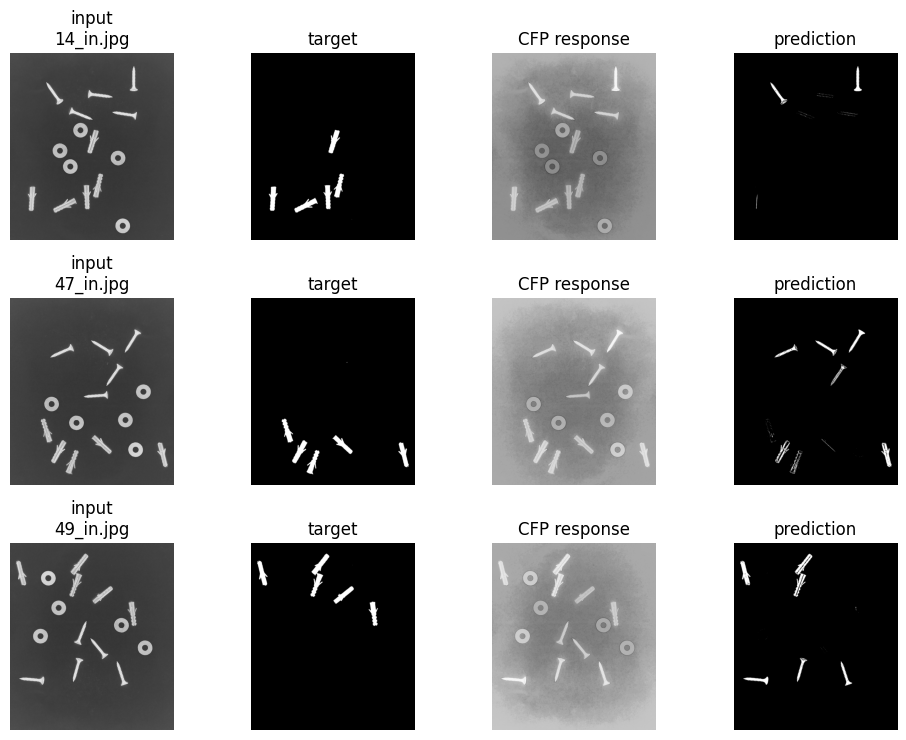

In [9]:
set_soft_threshold_gate(layer, learned_lambda)
sample_indices = list(range(min(3, len(test_cached))))
fig, axes = plt.subplots(len(sample_indices), 4, figsize=(10, 2.5 * len(sample_indices)))
if len(sample_indices) == 1:
    axes = axes[None, :]

with torch.no_grad():
    for row, sample_index in enumerate(sample_indices):
        sample = test_cached[sample_index]
        x, y, name = sample[:3]
        response = layer_response(layer, sample)
        response01 = image_minmax01(response)
        pred = response01 >= best_response_threshold

        panels = [x[0], y[0], response01, pred.float()]
        titles = [f"input\n{name}", "target", "CFP response", "prediction"]
        for col, (panel, title) in enumerate(zip(panels, titles)):
            axes[row, col].imshow(panel.detach().cpu(), cmap="gray", vmin=0, vmax=1)
            axes[row, col].set_title(title)
            axes[row, col].axis("off")

plt.tight_layout()
plt.show()

## Inspect node scores

A inspecao abaixo olha diretamente o atributo normalizado `LENGTH_MAJOR_AXIS`, o parametro aprendido `lambda_` e a distribuicao de scores produzida para os nos da max-tree.

In [10]:
x_inspect, _, inspect_name, inspect_idx = test_cached[0]
set_soft_threshold_gate(layer, learned_lambda)
info = layer.inspect_training_sample(x_inspect, idx=inspect_idx, build_if_missing=True)
spec_info = info["specs"][FILTER_KEY]
features = spec_info["norm_attrs"]
scorer = layer._scoring_models[FILTER_KEY]
scores = scorer(features.to(layer.device), beta_f=layer.beta_f, clamp=layer.clamp).detach().cpu()
lambda_value = scorer.lambda_.detach().cpu().view(-1)

summary = pd.DataFrame(
    {
        "item": ["num_nodes", "beta_f", "lambda", "score_min", "score_mean", "score_max"],
        "value": [
            int(features.shape[0]),
            float(layer.beta_f),
            float(lambda_value.item()),
            float(scores.min()),
            float(scores.mean()),
            float(scores.max()),
        ],
    }
)
parameters = pd.DataFrame(
    {
        "parameter": ["lambda_"],
        "meaning": [f"threshold for {ATTRIBUTE.name}"],
        "value": lambda_value.numpy(),
    }
)

print("sample:", inspect_name)
display(summary)
display(parameters)
display(pd.DataFrame(features[:8].cpu().numpy(), columns=[ATTRIBUTE.name]))

sample: 14_in.jpg


,item,value
0,num_nodes,104457.000000
1,beta_f,4.000000
2,lambda,0.804927
3,score_min,0.038431
4,score_mean,0.039319
5,score_max,0.685743


,parameter,meaning,value
0,lambda_,threshold for LENGTH_MAJOR_AXIS,0.804927


,LENGTH_MAJOR_AXIS
0,0.843910
1,0.843910
2,0.843910
3,0.843911
4,0.843912
5,0.843917
6,0.843924
7,0.843934


## Design takeaways

- `SingleAttributeSoftThresholdScorer` preserva a interpretacao de limiar morfologico: `lambda_` e o threshold aprendido no espaco do atributo normalizado.
- `beta_f` controla a suavidade da transicao e continua pertencendo ao contrato da camada CFP.
- O treino de 100 epocas otimiza somente `lambda_`; a regularizacao leve evita que o limiar perca completamente sua interpretacao.
- Como o scorer aceita exatamente um atributo, ele e mais interpretavel que um MLP e menos redundante que um modelo linear com temperatura.
- Para transformar este exemplo em API oficial, mova `SingleAttributeSoftThresholdScorer` para `mtlearn/python/mtlearn/layers/cfp/scoring/`, registre em `component_registries.py` como `single_attribute_soft_threshold` e adicione testes de export, `to_config` e forward.